# TabTrace — Exploratory Analysis

Exploration only. All logic used by the actual pipeline lives in `src/tabtrace/`, not here — this notebook exists to *show the reasoning* behind the engineered features, not to compute anything the pipeline depends on.

In [1]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from tabtrace.data.ingest import load_raw_dataset
from tabtrace.features.engineer import apply_features, feature_rationale_table

## 1. Load and inspect the raw dataset

In [2]:
X, y = load_raw_dataset()
print(X.shape, y.shape)
X.head()

(569, 30) (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Class balance

A quick check that the target isn't wildly imbalanced (relevant to why the split and CV are stratified in `tabtrace.data.split` and `tabtrace.models.tuned`).

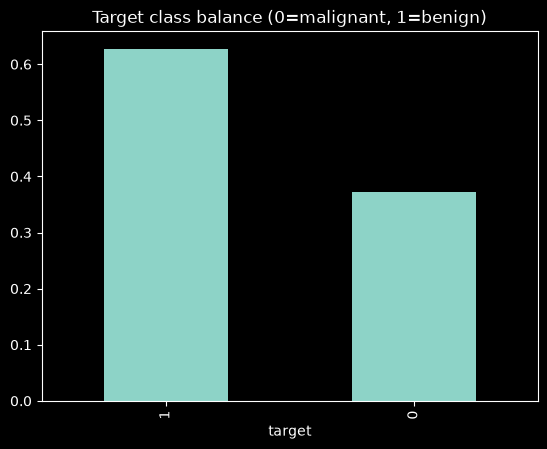

In [3]:
y.value_counts(normalize=True).plot(
    kind="bar", title="Target class balance (0=malignant, 1=benign)"
)
plt.show()

## 3. Why these three engineered features?

See `outputs/report.md` (generated by the pipeline) for the canonical justification text. This section visualizes the same intuition.

In [4]:
Xf = apply_features(X)
feature_rationale_table()

,feature,justification
0,area_perimeter_ratio,"Normalizes cell area by perimeter, capturing s..."
1,concavity_symmetry_interaction,Multiplies mean concavity by mean symmetry. Ma...
2,radius_worst_mean_ratio,Ratio of the most extreme ('worst') radius mea...


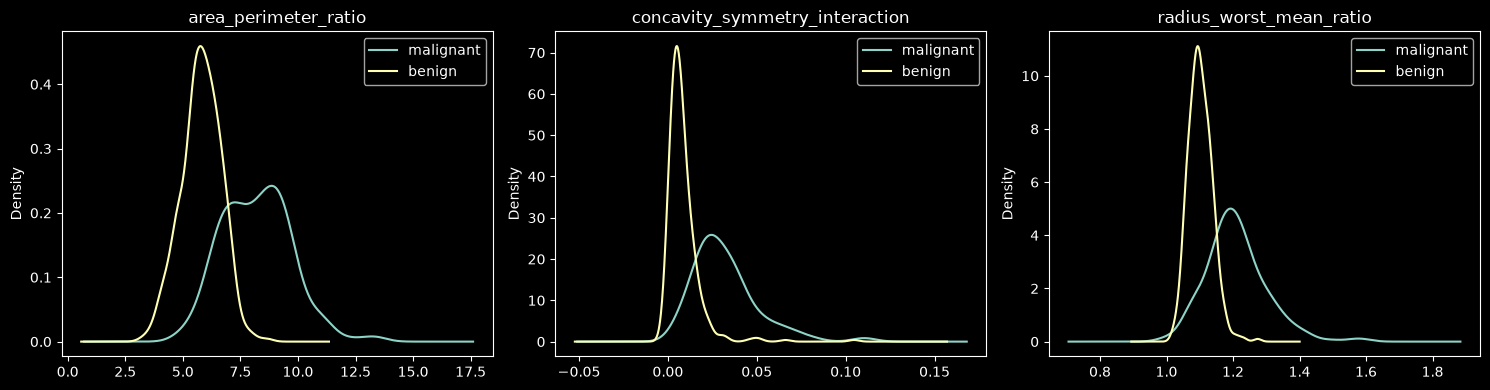

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(
    axes, ["area_perimeter_ratio", "concavity_symmetry_interaction", "radius_worst_mean_ratio"]
):
    for label, name in [(0, "malignant"), (1, "benign")]:
        Xf.loc[y == label, feat].plot(kind="kde", ax=ax, label=name)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Takeaway

Each engineered feature should visibly separate the two class densities more than the raw components it's built from — that separation is the empirical support behind the justification string registered in code, not just an assertion.